In [13]:
# ==========================================================
# IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import xgboost as xgb
import lightgbm as lgb

import sqlite3

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [14]:
# ==========================================================
# CONFIGURATION
# ==========================================================

conn = sqlite3.connect("data/machine_readings.db")

OEE_QUERY = '''SELECT 
    timestamp,
    MachineName,
    DivisionName,
    RunTime,
    DownTime,
    ProductionActual,
    ProductionRated,
    SpeedRated,
    SpeedActual,
    PlannedTime,
    Availability,
    Performance,
    Quality,
    OEE
FROM oee_daily_2025
WHERE DivisionName = 'UBR'
  AND timestamp BETWEEN '2025-01-01' AND '2025-06-30'
ORDER BY timestamp;'''

DOWN_QUERY = '''SELECT 
FromTime,
ToTime,
TotalTime,
MachineName,
DivisionName,
Reason
FROM downtime_info_2025
WHERE DivisionName = 'UBR'
AND TotalTime<=86400
AND FromTime BETWEEN '2025-01-01' AND '2025-06-30'
ORDER BY FromTime;'''

MODEL_TYPE = "xgb"

THRESHOLD = 0.6

LAG_DAYS = [1,3,7]
ROLL_WINDOWS = [3,7]

In [15]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def risk_level(prob):

    if prob > 0.7:
        return "HIGH"

    elif prob > 0.4:
        return "MEDIUM"

    else:
        return "LOW"

In [16]:
# ==========================================================
# LOAD DATA
# ==========================================================

oee = pd.read_sql_query(OEE_QUERY, conn)
down = pd.read_sql_query(DOWN_QUERY, conn)

print("OEE Data Shape:", oee.shape)
print("Downtime Data Shape:", down.shape)

oee.head()

OEE Data Shape: (6709, 14)
Downtime Data Shape: (157196, 6)


,timestamp,MachineName,DivisionName,RunTime,DownTime,ProductionActual,ProductionRated,SpeedRated,SpeedActual,PlannedTime,Availability,Performance,Quality,OEE
0,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0
1,2025-01-31 07:00:00,48B Armouring,UBR,20837,41563,4888.0,0.0,0.0,5.03,62400,33.39,0.0,100.0,0.0
2,2025-01-31 07:00:00,LAYING UP 1+3,UBR,0,62400,2.0,0.0,0.0,0.00,62400,0.00,0.0,100.0,0.0
3,2025-01-31 07:00:00,Nokia 90 MM,UBR,4813,21887,1502.0,0.0,0.0,3.53,26700,18.03,0.0,100.0,0.0
4,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0


In [17]:
oee = oee.replace("\\N", np.nan).infer_objects(copy=False)
down = down.replace("\\N", np.nan).infer_objects(copy=False)

In [18]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# Convert timestamps

oee['timestamp'] = pd.to_datetime(oee['timestamp'], format='mixed')
down['FromTime'] = pd.to_datetime(down['FromTime'], format='mixed')
down['ToTime'] = pd.to_datetime(down['ToTime'], format='mixed')

# Extract Date

oee['Date'] = oee['timestamp'].dt.date
down['Date'] = down['FromTime'].dt.date

# Machine names

oee['MachineName'] = oee['MachineName'].str.strip()
down['MachineName'] = down['MachineName'].str.strip()

# Fill missing reason

down['Reason'] = down['Reason'].fillna("Unknown")

oee.head()

,timestamp,MachineName,DivisionName,RunTime,DownTime,ProductionActual,ProductionRated,SpeedRated,SpeedActual,PlannedTime,Availability,Performance,Quality,OEE,Date
0,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0,2025-01-31
1,2025-01-31 07:00:00,48B Armouring,UBR,20837,41563,4888.0,0.0,0.0,5.03,62400,33.39,0.0,100.0,0.0,2025-01-31
2,2025-01-31 07:00:00,LAYING UP 1+3,UBR,0,62400,2.0,0.0,0.0,0.00,62400,0.00,0.0,100.0,0.0,2025-01-31
3,2025-01-31 07:00:00,Nokia 90 MM,UBR,4813,21887,1502.0,0.0,0.0,3.53,26700,18.03,0.0,100.0,0.0,2025-01-31
4,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0,2025-01-31


In [19]:
# ==========================================================
# DAILY DATASET
# ==========================================================

daily_oee = oee.groupby(['MachineName','Date']).agg(

    RunTime=('RunTime','sum'),
    DownTime=('DownTime','sum'),

    ProductionActual=('ProductionActual','sum'),
    ProductionRated=('ProductionRated','sum'),

    SpeedActual=('SpeedActual','mean'),
    SpeedRated=('SpeedRated','mean'),

    OEE=('OEE','mean')

).reset_index()


down_daily = down.groupby(['MachineName','Date']).agg(

    Daily_Downtime=('TotalTime','sum'),
    Stop_Count=('TotalTime','size')

).reset_index()

daily_df = daily_oee.merge(down_daily,on=['MachineName','Date'],how='left')

daily_df[['Daily_Downtime','Stop_Count']] = daily_df[['Daily_Downtime','Stop_Count']].fillna(0)

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,Stop_Count
0,120 MM Ext U3,2025-01-31,0,119880,0.0,0.0,0.00,0.0,0.0,0.000000,0.0
1,120 MM Ext U3,2025-02-01,5700,167100,620.0,0.0,0.22,0.0,0.0,602.721250,1.0
2,120 MM Ext U3,2025-02-02,86160,86640,10822.0,0.0,3.84,0.0,0.0,39485.465869,5.0
3,120 MM Ext U3,2025-02-03,100454,72346,15838.0,0.0,5.70,0.0,0.0,9122.900498,6.0
4,120 MM Ext U3,2025-02-04,0,172800,0.0,0.0,0.00,0.0,0.0,0.000000,0.0


In [20]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

daily_df = daily_df.sort_values(['MachineName','Date'])


features = [

    'OEE','RunTime','DownTime',
    'ProductionActual','ProductionRated',
    'SpeedActual','SpeedRated',
    'Daily_Downtime','Stop_Count'

]


for feat in features:

    for lag in LAG_DAYS:

        daily_df[f"{feat}_lag{lag}"] = daily_df.groupby('MachineName')[feat].shift(lag)



for feat in ['RunTime','DownTime','OEE','Daily_Downtime','Stop_Count']:

    for window in ROLL_WINDOWS:

        daily_df[f"{feat}_rollmean_{window}"] = daily_df.groupby('MachineName')[feat].transform(
            lambda x: x.rolling(window).mean()
        )

        daily_df[f"{feat}_rollstd_{window}"] = daily_df.groupby('MachineName')[feat].transform(
            lambda x: x.rolling(window).std()
        )


daily_df['Stop_3day'] = daily_df.groupby('MachineName')['Stop_Count'].transform(
    lambda x: x.rolling(3).sum()
)

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,OEE_rollstd_7,Daily_Downtime_rollmean_3,Daily_Downtime_rollstd_3,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day
0,120 MM Ext U3,2025-01-31,0,119880,0.0,0.0,0.00,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120 MM Ext U3,2025-02-01,5700,167100,620.0,0.0,0.22,0.0,0.0,602.721250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120 MM Ext U3,2025-02-02,86160,86640,10822.0,0.0,3.84,0.0,0.0,39485.465869,...,NaN,13362.729040,22624.960836,NaN,NaN,2.000000,2.645751,NaN,NaN,6.0
3,120 MM Ext U3,2025-02-03,100454,72346,15838.0,0.0,5.70,0.0,0.0,9122.900498,...,NaN,16403.695872,20438.308228,NaN,NaN,4.000000,2.645751,NaN,NaN,12.0
4,120 MM Ext U3,2025-02-04,0,172800,0.0,0.0,0.00,0.0,0.0,0.000000,...,NaN,16202.788789,20672.907811,NaN,NaN,3.666667,3.214550,NaN,NaN,11.0


In [21]:
# ==========================================================
# CREATE TARGET
# ==========================================================

daily_df['Current_Degrading'] = np.where(

    (daily_df['OEE'] < 70) &
    (daily_df['Daily_Downtime'] / (daily_df['RunTime'] + daily_df['Daily_Downtime']) > 0.25),

    1,0
)

daily_df['Target'] = daily_df.groupby('MachineName')['Current_Degrading'].shift(-1)

daily_df = daily_df.dropna(subset=['Target'])

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,Daily_Downtime_rollstd_3,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day,Current_Degrading,Target
0,120 MM Ext U3,2025-01-31,0,119880,0.0,0.0,0.00,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
1,120 MM Ext U3,2025-02-01,5700,167100,620.0,0.0,0.22,0.0,0.0,602.721250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0
2,120 MM Ext U3,2025-02-02,86160,86640,10822.0,0.0,3.84,0.0,0.0,39485.465869,...,22624.960836,NaN,NaN,2.000000,2.645751,NaN,NaN,6.0,1,0.0
3,120 MM Ext U3,2025-02-03,100454,72346,15838.0,0.0,5.70,0.0,0.0,9122.900498,...,20438.308228,NaN,NaN,4.000000,2.645751,NaN,NaN,12.0,0,0.0
4,120 MM Ext U3,2025-02-04,0,172800,0.0,0.0,0.00,0.0,0.0,0.000000,...,20672.907811,NaN,NaN,3.666667,3.214550,NaN,NaN,11.0,0,0.0


In [22]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

daily_df['MachineID'] = le.fit_transform(daily_df['MachineName'])

In [23]:
# ==========================================================
# TIME BASED SPLIT
# ==========================================================

feature_cols = [col for col in daily_df.columns if ('lag' in col or 'roll' in col)]

feature_cols.append("MachineID")

split_date = daily_df['Date'].quantile(0.8)

train_df = daily_df[daily_df['Date'] <= split_date]
test_df = daily_df[daily_df['Date'] > split_date]

X_train = train_df[feature_cols]
y_train = train_df['Target']

X_test = test_df[feature_cols]
y_test = test_df['Target']

print(X_train.shape)
print(X_test.shape)

(2375, 48)
(585, 48)


In [24]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(

    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"

)

model.fit(X_train,y_train)

print("Model Training Completed")

Model Training Completed


In [25]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > THRESHOLD).astype(int)

print("Accuracy:",accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       195
         1.0       0.92      0.87      0.90       390

    accuracy                           0.87       585
   macro avg       0.85      0.86      0.85       585
weighted avg       0.87      0.87      0.87       585



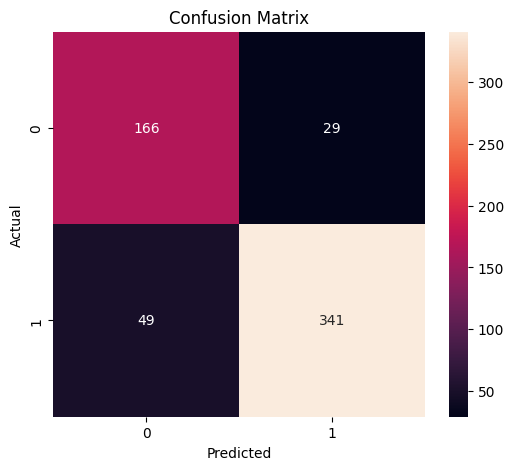


Confusion Matrix:
 [[166  29]
 [ 49 341]]


In [26]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.show()
print("\nConfusion Matrix:\n", cm)

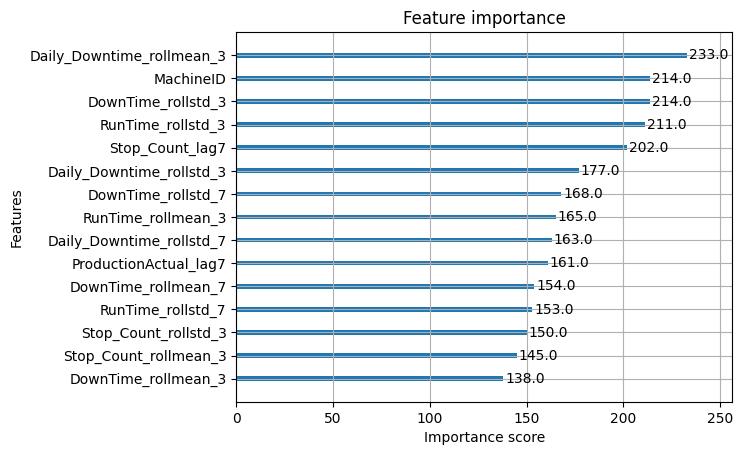

In [27]:
xgb.plot_importance(model,max_num_features=15)

plt.show()

In [28]:
# ==========================================================
# MACHINE HEALTH
# ==========================================================

results = test_df[['MachineName','Date']].copy()

results["Degradation_Probability"] = y_prob.round(4)

results["Health_Score"] = ((1 - y_prob) * 100).round(2)

results["Risk_Level"] = [risk_level(p) for p in y_prob]

# Latest machine status
results = results.sort_values("Date")

results = results.groupby("MachineName").tail(1)

# Priority machines first
results = results.sort_values("Health_Score")

results.head(10)

,MachineName,Date,Degradation_Probability,Health_Score,Risk_Level
1788,HEAVY REWINDING 03 U3,2025-06-28,0.9992,0.08,HIGH
2537,Strip Rw 01 U2 (72Arm),2025-06-28,0.9985,0.15,HIGH
2788,Strip Rw 06 U4 (72Arm),2025-06-28,0.9982,0.18,HIGH
2592,Strip Rw 02 U2 (72Arm),2025-06-28,0.9970,0.30,HIGH
1577,Drum twister(DT)-2,2025-06-28,0.9959,0.41,HIGH
1333,Cu Tapping - E,2025-06-28,0.9956,0.44,HIGH
1504,DT1 4000 MM,2025-06-27,0.9948,0.52,HIGH
2647,Strip Rw 03 U2 (72Arm),2025-06-28,0.9945,0.55,HIGH
2730,Strip Rw 04 U4 (72Arm),2025-06-28,0.9938,0.62,HIGH
1435,Cu Tapping - G,2025-06-17,0.9938,0.62,HIGH


In [29]:
# ==========================================================
# OPERATOR SUGGESTIONS
# ==========================================================

def operator_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Check machine cleaning, lubrication and alignment"

    elif row["Risk_Level"] == "MEDIUM":
        return "Monitor machine speed and minor stoppages"

    else:
        return "Machine running normal"


results["Operator_Action"] = results.apply(operator_action,axis=1)

In [30]:
# ==========================================================
# SHIFT INCHARGE ACTION
# ==========================================================

def shift_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Plan maintenance before next shift"

    elif row["Risk_Level"] == "MEDIUM":
        return "Monitor performance and reduce minor stops"

    else:
        return "No action required"


results["Shift_Incharge_Action"] = results.apply(shift_action,axis=1)

In [31]:
# ==========================================================
# MANAGER ACTION
# ==========================================================

def manager_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Schedule preventive maintenance"

    elif row["Risk_Level"] == "MEDIUM":
        return "Investigate root cause of downtime"

    else:
        return "Production stable"


results["Manager_Action"] = results.apply(manager_action,axis=1)

In [32]:
results.head(20)

,MachineName,Date,Degradation_Probability,Health_Score,Risk_Level,Operator_Action,Shift_Incharge_Action,Manager_Action
1788,HEAVY REWINDING 03 U3,2025-06-28,0.9992,0.08,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2537,Strip Rw 01 U2 (72Arm),2025-06-28,0.9985,0.15,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2788,Strip Rw 06 U4 (72Arm),2025-06-28,0.9982,0.18,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2592,Strip Rw 02 U2 (72Arm),2025-06-28,0.9970,0.30,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1577,Drum twister(DT)-2,2025-06-28,0.9959,0.41,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1333,Cu Tapping - E,2025-06-28,0.9956,0.44,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1504,DT1 4000 MM,2025-06-27,0.9948,0.52,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2647,Strip Rw 03 U2 (72Arm),2025-06-28,0.9945,0.55,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2730,Strip Rw 04 U4 (72Arm),2025-06-28,0.9938,0.62,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1435,Cu Tapping - G,2025-06-17,0.9938,0.62,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


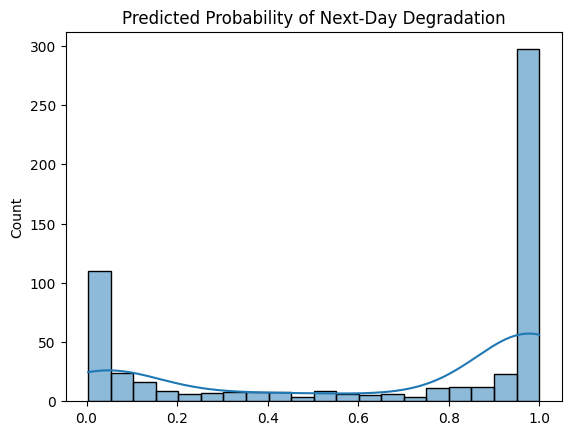

In [33]:
# =====================================================
# PROBABILITY DISTRIBUTION
# =====================================================

sns.histplot(y_prob, bins=20, kde=True)

plt.title("Predicted Probability of Next-Day Degradation")

plt.show()

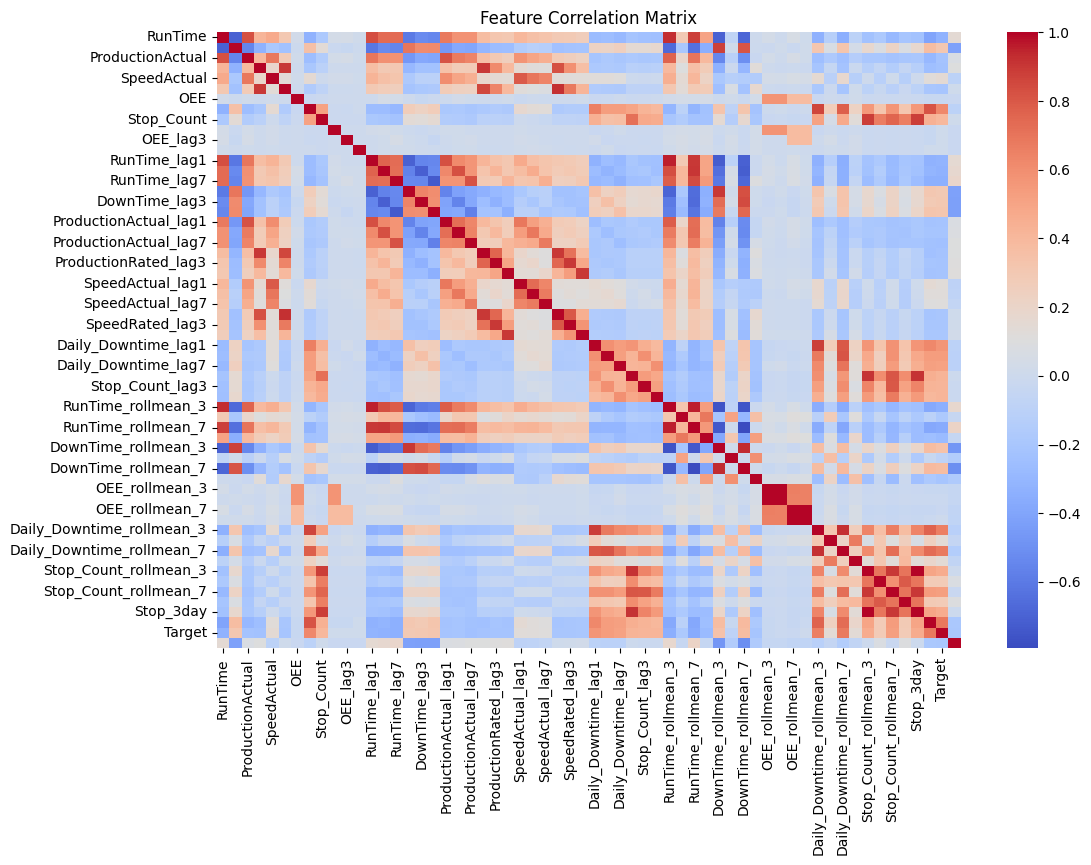

In [34]:
# =====================================================
# FEATURE CORRELATION
# =====================================================

corr_matrix = daily_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [35]:
# =====================================================
# PRINT HIGH RISK MACHINES
# =====================================================

for _, row in results.head(10).iterrows():

    print(f"""
Machine: {row['MachineName']}
Health Score: {row['Health_Score']:.2f}
Risk Level: {row['Risk_Level']}
----------------------------
""")


Machine: HEAVY REWINDING 03 U3
Health Score: 0.08
Risk Level: HIGH
----------------------------


Machine: Strip Rw 01 U2 (72Arm)
Health Score: 0.15
Risk Level: HIGH
----------------------------


Machine: Strip Rw 06 U4 (72Arm)
Health Score: 0.18
Risk Level: HIGH
----------------------------


Machine: Strip Rw 02 U2 (72Arm)
Health Score: 0.30
Risk Level: HIGH
----------------------------


Machine: Drum twister(DT)-2
Health Score: 0.41
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - E
Health Score: 0.44
Risk Level: HIGH
----------------------------


Machine: DT1  4000 MM
Health Score: 0.52
Risk Level: HIGH
----------------------------


Machine: Strip Rw 03 U2 (72Arm)
Health Score: 0.55
Risk Level: HIGH
----------------------------


Machine: Strip Rw 04 U4 (72Arm)
Health Score: 0.62
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - G
Health Score: 0.62
Risk Level: HIGH
----------------------------



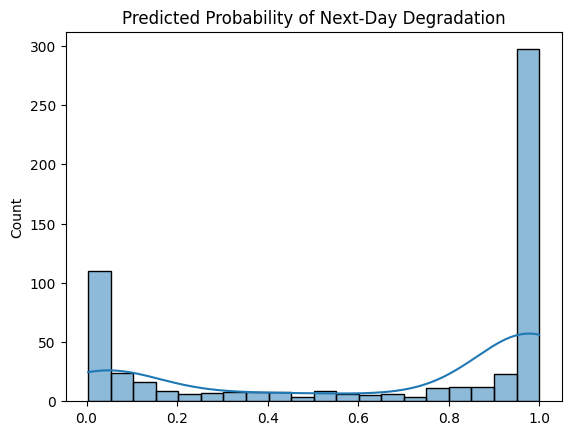

In [36]:
sns.histplot(y_prob, bins=20, kde=True)

plt.title("Predicted Probability of Next-Day Degradation")

plt.show()

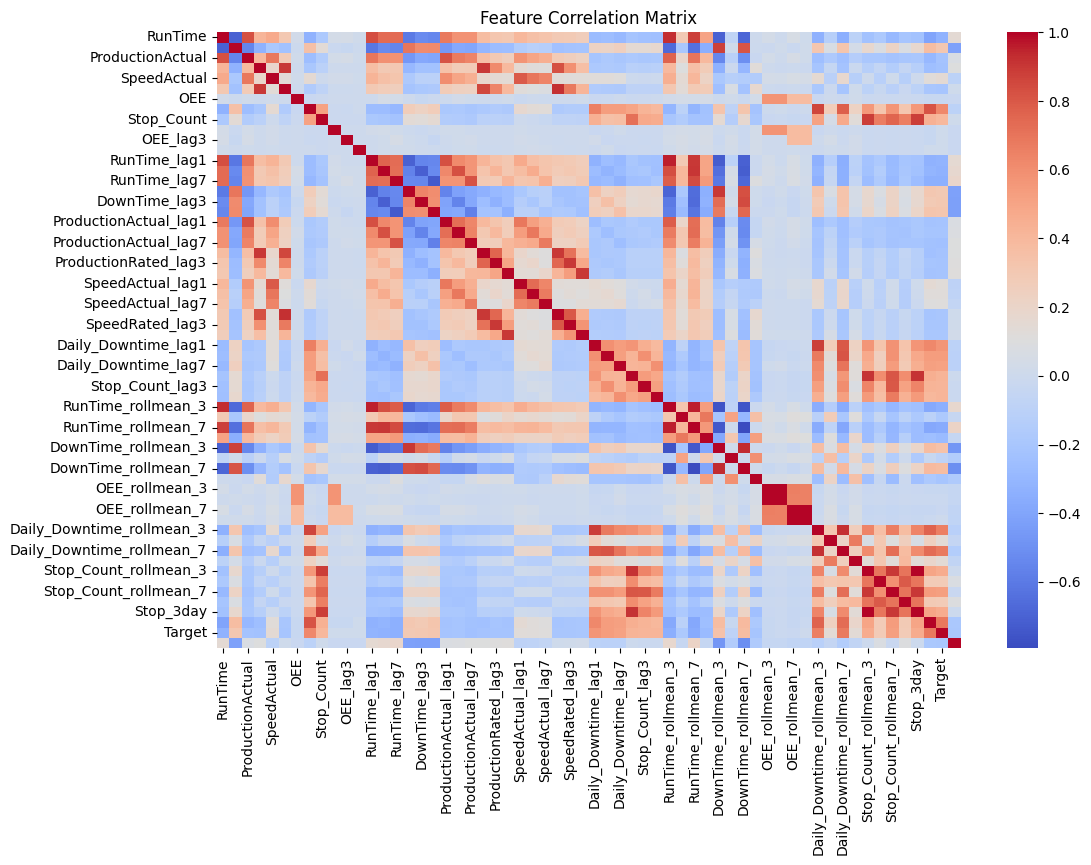

In [37]:
corr_matrix = daily_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [38]:
# from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, val_idx in tscv.split(X_train):
#     X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#     y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#     model.fit(X_tr, y_tr)
#     y_pred = model.predict(X_val)
#     print(classification_report(y_val, y_pred))

In [39]:
daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day,Current_Degrading,Target,MachineID
0,120 MM Ext U3,2025-01-31,0,119880,0.0,0.0,0.00,0.0,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0
1,120 MM Ext U3,2025-02-01,5700,167100,620.0,0.0,0.22,0.0,0.0,602.721250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,0
2,120 MM Ext U3,2025-02-02,86160,86640,10822.0,0.0,3.84,0.0,0.0,39485.465869,...,NaN,NaN,2.000000,2.645751,NaN,NaN,6.0,1,0.0,0
3,120 MM Ext U3,2025-02-03,100454,72346,15838.0,0.0,5.70,0.0,0.0,9122.900498,...,NaN,NaN,4.000000,2.645751,NaN,NaN,12.0,0,0.0,0
4,120 MM Ext U3,2025-02-04,0,172800,0.0,0.0,0.00,0.0,0.0,0.000000,...,NaN,NaN,3.666667,3.214550,NaN,NaN,11.0,0,0.0,0


In [40]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2960 entries, 0 to 3011
Data columns (total 62 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MachineName                2960 non-null   object 
 1   Date                       2960 non-null   object 
 2   RunTime                    2960 non-null   int64  
 3   DownTime                   2960 non-null   int64  
 4   ProductionActual           2960 non-null   float64
 5   ProductionRated            2960 non-null   float64
 6   SpeedActual                2960 non-null   float64
 7   SpeedRated                 2960 non-null   float64
 8   OEE                        2960 non-null   float64
 9   Daily_Downtime             2960 non-null   float64
 10  Stop_Count                 2960 non-null   float64
 11  OEE_lag1                   2908 non-null   float64
 12  OEE_lag3                   2804 non-null   float64
 13  OEE_lag7                   2597 non-null   float64
 1

In [41]:
# ======================================================
# CHECK TARGET DISTRIBUTION
# ======================================================

daily_df["Target"].value_counts()

Target
1.0    1633
0.0    1327
Name: count, dtype: int64

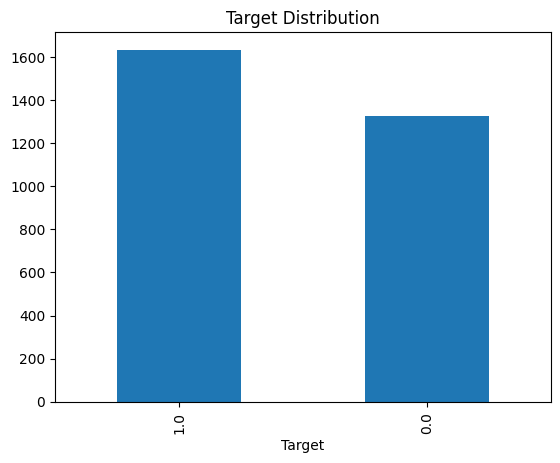

In [42]:
daily_df["Target"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.show()

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       195
         1.0       0.92      0.87      0.90       390

    accuracy                           0.87       585
   macro avg       0.85      0.86      0.85       585
weighted avg       0.87      0.87      0.87       585



In [44]:
check_df = test_df[['MachineName','Date']].copy()

check_df["Actual"] = y_test.values
check_df["Predicted"] = y_pred
check_df["Probability"] = y_prob

check_df.head(20)

,MachineName,Date,Actual,Predicted,Probability
122,120 MM Ext U3,2025-06-10,1.0,0,0.311391
123,120 MM Ext U3,2025-06-11,1.0,0,0.264125
124,120 MM Ext U3,2025-06-12,0.0,0,0.587688
125,120 MM Ext U3,2025-06-13,0.0,0,0.546520
126,120 MM Ext U3,2025-06-14,1.0,0,0.446754
127,120 MM Ext U3,2025-06-15,1.0,0,0.117498
128,120 MM Ext U3,2025-06-16,0.0,1,0.657152
129,120 MM Ext U3,2025-06-17,1.0,0,0.411162
130,120 MM Ext U3,2025-06-18,1.0,0,0.338635
131,120 MM Ext U3,2025-06-19,0.0,0,0.595207


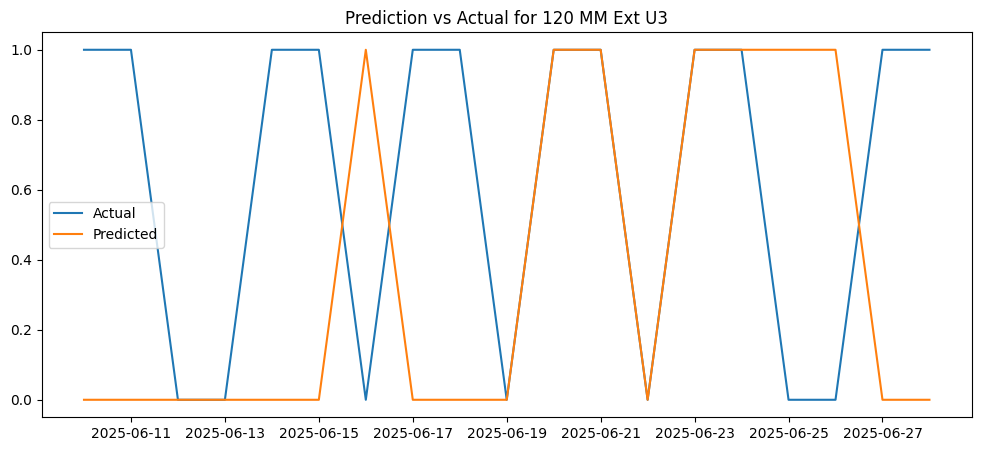

In [45]:
machine = check_df["MachineName"].iloc[0]

machine_df = check_df[check_df["MachineName"] == machine]

plt.figure(figsize=(12,5))

plt.plot(machine_df["Date"], machine_df["Actual"], label="Actual")

plt.plot(machine_df["Date"], machine_df["Predicted"], label="Predicted")

plt.legend()

plt.title(f"Prediction vs Actual for {machine}")

plt.show()

In [46]:
importance = pd.DataFrame({

"Feature":feature_cols,
"Importance":model.feature_importances_

}).sort_values("Importance",ascending=False)

importance.head(20)

,Feature,Importance
43,Stop_Count_rollmean_3,0.398889
29,RunTime_rollmean_7,0.053476
39,Daily_Downtime_rollmean_3,0.030116
27,RunTime_rollmean_3,0.019483
42,Daily_Downtime_rollstd_7,0.018257
31,DownTime_rollmean_3,0.015888
45,Stop_Count_rollmean_7,0.015466
18,SpeedRated_lag1,0.015265
30,RunTime_rollstd_7,0.015105
26,Stop_Count_lag7,0.014794


In [47]:
train_pred = model.predict(X_train)

print("Train Accuracy:",accuracy_score(y_train,train_pred))
print("Test Accuracy:",accuracy_score(y_test,y_pred))

Train Accuracy: 0.9869473684210527
Test Accuracy: 0.8666666666666667


In [48]:
np.random.seed(42)

sample = check_df.sample(20)

sample

,MachineName,Date,Actual,Predicted,Probability
2244,Sioplas MVCC 3,2025-06-16,0.0,0,0.525007
2428,Sioplas MVCC 5,2025-06-22,0.0,0,0.109735
783,72B ARMORING U2,2025-06-24,1.0,1,0.989542
2640,Strip Rw 03 U2 (72Arm),2025-06-13,0.0,1,0.829332
2759,Strip Rw 05 U4 (72Arm),2025-06-28,0.0,0,0.017214
1771,HEAVY REWINDING 03 U3,2025-06-11,1.0,1,0.995997
836,CCV Sloze U4,2025-06-25,0.0,0,0.017485
1574,Drum twister(DT)-2,2025-06-25,1.0,1,0.991030
1023,Cu Tapping - A,2025-06-28,0.0,0,0.028049
2052,SioPlas U3,2025-06-25,1.0,0,0.062378


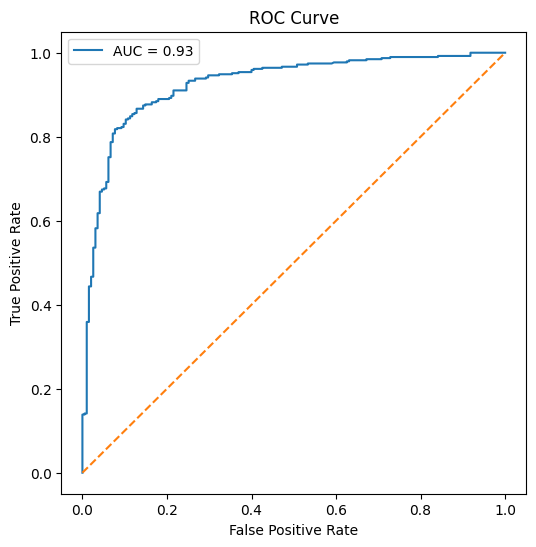

In [49]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

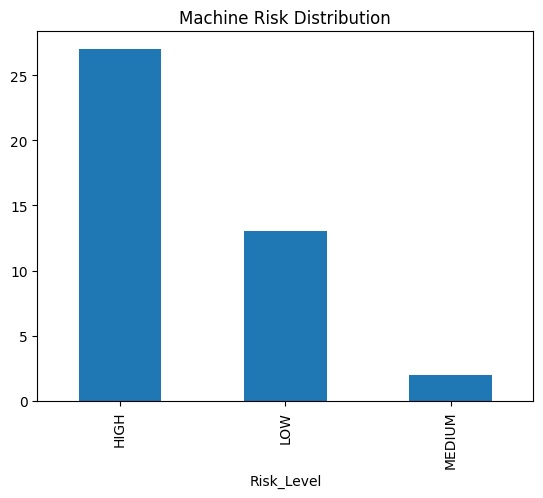

In [50]:
results["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Machine Risk Distribution")

plt.show()

In [51]:
# ======================================================
# FINAL DASHBOARD TABLE
# ======================================================

final_table = results[[
    
    "MachineName",
    "Risk_Level",
    "Health_Score",
    "Operator_Action",
    "Shift_Incharge_Action",
    "Manager_Action"
]]

final_table.head(20)

,MachineName,Risk_Level,Health_Score,Operator_Action,Shift_Incharge_Action,Manager_Action
1788,HEAVY REWINDING 03 U3,HIGH,0.08,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2537,Strip Rw 01 U2 (72Arm),HIGH,0.15,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2788,Strip Rw 06 U4 (72Arm),HIGH,0.18,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2592,Strip Rw 02 U2 (72Arm),HIGH,0.30,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1577,Drum twister(DT)-2,HIGH,0.41,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1333,Cu Tapping - E,HIGH,0.44,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1504,DT1 4000 MM,HIGH,0.52,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2647,Strip Rw 03 U2 (72Arm),HIGH,0.55,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2730,Strip Rw 04 U4 (72Arm),HIGH,0.62,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1435,Cu Tapping - G,HIGH,0.62,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


In [52]:
top_risk = final_table.sort_values("Health_Score")

top_risk.head(10)

,MachineName,Risk_Level,Health_Score,Operator_Action,Shift_Incharge_Action,Manager_Action
1788,HEAVY REWINDING 03 U3,HIGH,0.08,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2537,Strip Rw 01 U2 (72Arm),HIGH,0.15,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2788,Strip Rw 06 U4 (72Arm),HIGH,0.18,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2592,Strip Rw 02 U2 (72Arm),HIGH,0.30,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1577,Drum twister(DT)-2,HIGH,0.41,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1333,Cu Tapping - E,HIGH,0.44,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1504,DT1 4000 MM,HIGH,0.52,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2647,Strip Rw 03 U2 (72Arm),HIGH,0.55,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2730,Strip Rw 04 U4 (72Arm),HIGH,0.62,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1435,Cu Tapping - G,HIGH,0.62,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


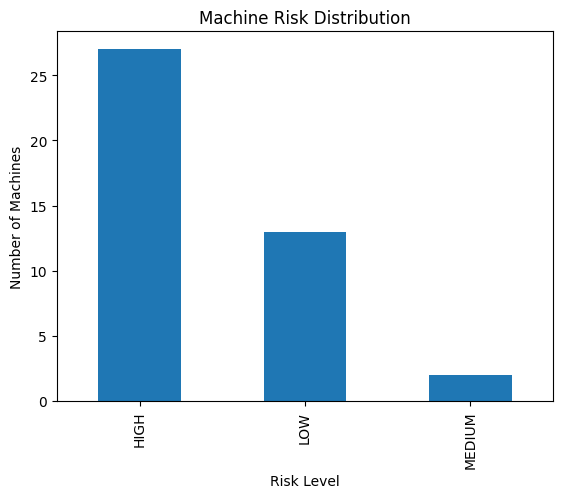

In [53]:
results["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Machine Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Machines")

plt.show()

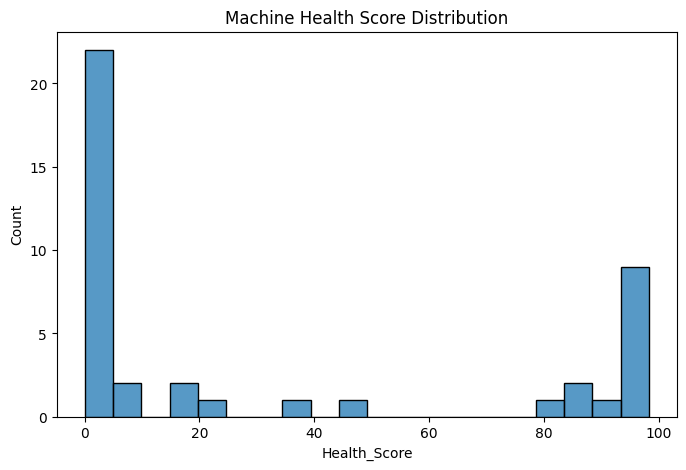

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(results["Health_Score"], bins=20)

plt.title("Machine Health Score Distribution")

plt.show()

In [55]:
final_table.to_csv("machine_health_report.csv", index=False)

In [56]:
import joblib

joblib.dump(model,"model.pkl")

['model.pkl']